### 1. Create and train

#### 1.1 Load and reshape MNIST dataset

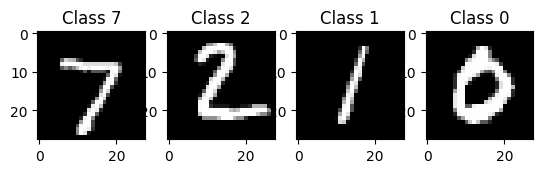

In [1]:
import numpy as np
import tensorflow as tf
import keras

import matplotlib.cm as cm
import matplotlib.pyplot as plt

from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# add a channel dimension as Akida excepts 4-D (num_samples, height, width, channels)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

f, axarr = plt.subplots(1, 4)
for i in range(0, 4):
    axarr[i].imshow(x_test[i].reshape((28, 28)), cmap=cm.Greys_r)
    axarr[i].set_title('Class %d' % y_test[i])
plt.show()


#### 1.2 Model definition

In [2]:
model_keras = keras.models.Sequential([
    keras.layers.Input(shape=(28, 28, 1), name="input", dtype=tf.uint8),
    keras.layers.Rescaling(1. / 255),
    keras.layers.Conv2D(filters=32, kernel_size=3, strides=2),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    # Separable layer
    keras.layers.DepthwiseConv2D(kernel_size=3, padding='same', strides=2),
    keras.layers.Conv2D(filters=64, kernel_size=1, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.Flatten(),
    keras.layers.Dense(10)
], 'mnistnet')

model_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 7, 7, 32)       │           320 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,506 (134.79 KB)

 Trainable params: 34,314 (134.04 KB)

 Non-trainable params: 192 (768.00 B)

#### 1.3 Model training

In [8]:
from keras.optimizers import Adam

model_keras.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

_ = model_keras.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9479 - loss: 0.1729 - val_accuracy: 0.9773 - val_loss: 0.0765
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9784 - loss: 0.0691 - val_accuracy: 0.9830 - val_loss: 0.0622
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9839 - loss: 0.0510 - val_accuracy: 0.9847 - val_loss: 0.0570
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9865 - loss: 0.0414 - val_accuracy: 0.9850 - val_loss: 0.0597
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9891 - loss: 0.0329 - val_accuracy: 0.9812 - val_loss: 0.0747
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9901 - loss: 0.0292 - val_accuracy: 0.9863 - val_loss: 0.0592
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9919 - loss: 0.0236 - val_accuracy: 0.9872 - val_loss: 0.0545
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9923 - loss: 0.02

In [9]:
score = model_keras.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: ", score)

Test accuracy:  [0.05822182074189186, 0.982699990272522]


### 2. Quantize

In [1]:
import sys
print(sys.executable)
print('\n'.join(sys.path))

/usr/bin/python3
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/usr/lib/python3/dist-packages
/usr/local/lib/python3.12/dist-packages/IPython/extensions
/root/.ipython


In [3]:
from quantizeml.models import quantize, QuantizationParams

qparams = QuantizationParams(input_weight_bits=8, weight_bits=8, activation_bits=8)
model_quantized = quantize(model_keras, qparams=qparams)

ModuleNotFoundError: No module named 'quantizeml'